Bad pipe message: %s [b' 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Sa']
Bad pipe message: %s [b'ri/537.36\r\nAccept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/', b'ng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7\r\nAccept-Encoding: gzip, deflate, br, zstd\r\nA']
Bad pipe message: %s [b'ept-Language: en-ID,en;q=0.9,id-ID;q=0.8,id;q=0.7,en-GB;q=0.6,en-US;q=0.5\r\nPriority: u=0, i\r\nRefer', b': https://studio.firebase.google.com/\r\nSec-Ch-Ua: "Not(A:Brand";v="8", "Chromium";v="144", "Google C']
Bad pipe message: %s [b'ome";v="144"\r\nSec-Ch-Ua-Arch: "x86"\r\nSec-Ch-Ua-Bitness: "64"\r\nSec-Ch-Ua-Form-Factors: "Desktop"\r\nSec-Ch']
Bad pipe message: %s [b'a-Full-Version: "144.0.7559.97"\r\nSec-Ch-Ua-F', b'l-Version-List: "Not(A:Brand";v="8.0.0.0", "Chromium";v="144.0.7559.97", "Google Chrome";v="144.0.7559.97"\r\nSec-Ch-U']
Bad pipe message: %s [b'Mobile: ?0\r\nSec-Ch-Ua-Model: ""\r\nSec-Ch-Ua-Platform: "Windows"\

📁 Loading sentiment analysis results...
✅ Loaded BERT sentiment results: (2298, 6)
📋 Using BERT sentiment data

🔍 Data preview:
   comment_id                                   original_comment  \
0           1  om coba minecraft java pake shders derrative p...   
1           2  tambahin honor of kings dong om sebagai salah ...   
2           4  cuma yang gua gak suka dari poco ini yaitu blo...   
3           8                thn depan auto naik harga dan ghoib   
4          11    untuk jangka panjang apakah poco f ini worth it   

                aspects          sentiments   confidences  aspect_count  
0               Display             neutral         0.997             1  
1  Display, Performance  positive, positive  0.658, 0.658             2  
2              Security            positive         0.948             1  
3                 Price             neutral         0.908             1  
4                 Price            positive         0.985             1  

🔧 Preparing data f

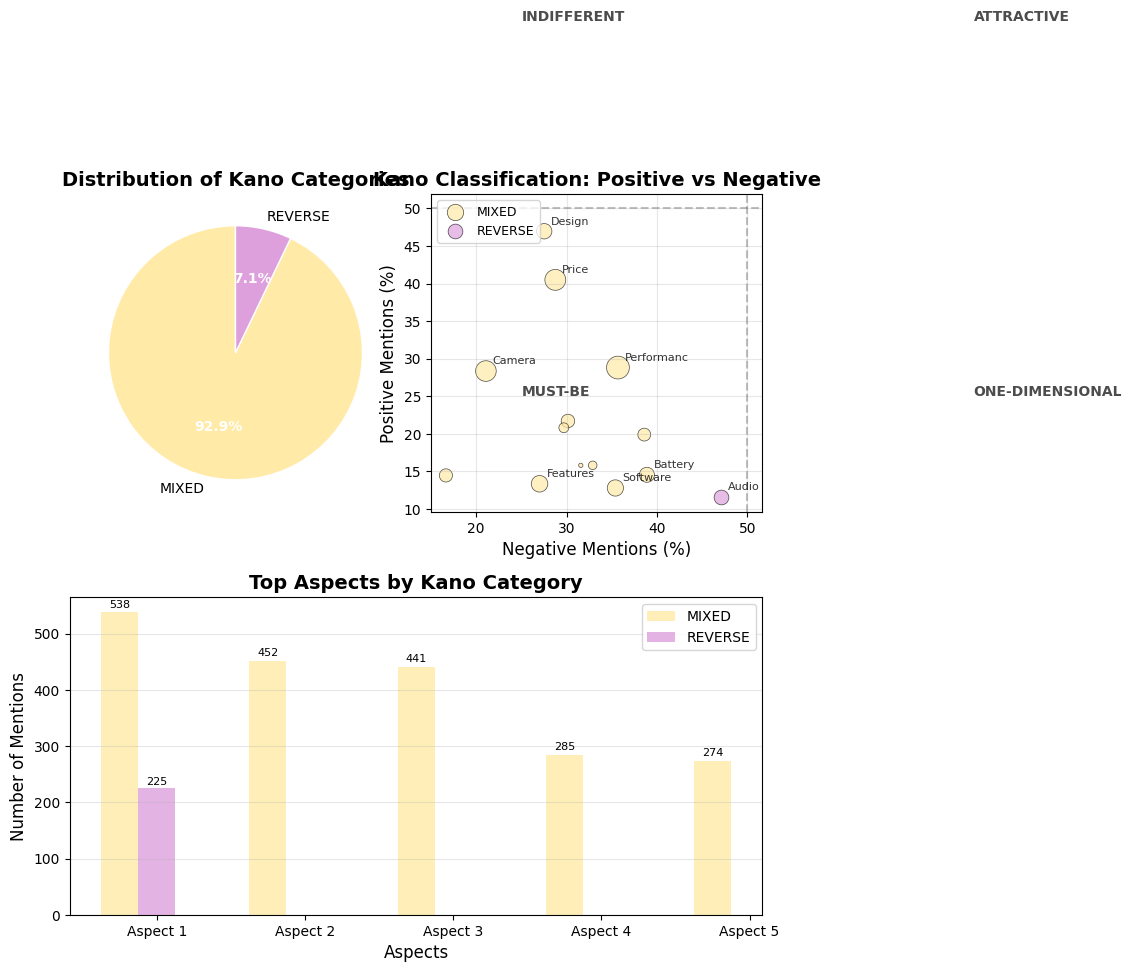

📊 Visualization saved as 'kano_analysis_visualization.png'

🚀 NPD (NEW PRODUCT DEVELOPMENT) RECOMMENDATIONS

🎯 PRIORITY 1: MUST-BE FEATURES (Fix Immediately)
------------------------------------------------------------
No MUST-BE features identified. Good news!

🎯 PRIORITY 2: ONE-DIMENSIONAL FEATURES (Competitive Advantage)
------------------------------------------------------------

🎯 PRIORITY 3: ATTRACTIVE FEATURES (Differentiators)
------------------------------------------------------------

🎯 LOW PRIORITY: INDIFFERENT FEATURES
------------------------------------------------------------

💾 Saving all results...
✅ Kano classification saved to: ../data/kano_res/kano_classification_results.csv
✅ NPD recommendations saved to: ../data/kano_res/json/npd_recommendations.json
✅ Executive summary saved to: ../data/usefuldict/executive_summary.txt

🎉 KANO ANALYSIS COMPLETED SUCCESSFULLY!

📊 RESULTS SUMMARY:
  • Total aspects analyzed: 14
  • Customer comments processed: 2298
  • MIXED     

In [1]:
import pandas as pd
import numpy as np
import json
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== 1. LOAD SENTIMENT RESULTS ====================
print("📁 Loading sentiment analysis results...")

# Pilih file mana yang mau dipakai:
# OPTION A: CSV hasil BERT aspect-specific sentiment
# sentiment_file = "aspect_specific_sentiment_results.csv"

# OPTION B: Jika belum punya file BERT, kita buat dari data aspect detection
# dengan sentiment dummy untuk testing
aspect_file = "../data/comment_and_aspects/aspect_detection_results.csv"  # File aspect detection Anda

try:
    # Coba load hasil BERT
    df = pd.read_csv("../data/absa_sentiment_detected/aspect_specific_sentiment_results.csv")
    print(f"✅ Loaded BERT sentiment results: {df.shape}")
    
    # Parse kolom yang ada
    if 'sentiments' in df.columns:
        print("📋 Using BERT sentiment data")
        use_bert_data = True
    else:
        raise FileNotFoundError
        
except:
    print("⚠️  BERT sentiment file not found. Creating from aspect detection data...")
    df = pd.read_csv(aspect_file)
    use_bert_data = False
    print(f"✅ Loaded aspect detection data: {df.shape}")

print(f"\n🔍 Data preview:")
print(df.head())

# ==================== 2. PREPARE DATA ====================
print("\n🔧 Preparing data for Kano analysis...")

def prepare_kano_data(df, use_bert=True):
    """
    Siapkan data dalam format untuk analisis Kano
    """
    aspect_data = defaultdict(lambda: {
        'total_mentions': 0,
        'positive': 0,
        'negative': 0,
        'neutral': 0,
        'comments': []
    })
    
    if use_bert:
        # Jika pakai data BERT (format: aspects, sentiments, confidences)
        for _, row in df.iterrows():
            if pd.isna(row['aspects']):
                continue
                
            aspects = [a.strip() for a in str(row['aspects']).split(',')]
            sentiments = [s.strip() for s in str(row['sentiments']).split(',')]
            
            for aspect, sentiment in zip(aspects, sentiments):
                stats = aspect_data[aspect]
                stats['total_mentions'] += 1
                
                if sentiment == 'positive':
                    stats['positive'] += 1
                elif sentiment == 'negative':
                    stats['negative'] += 1
                else:
                    stats['neutral'] += 1
                
                # Simpan sample comment (maks 5)
                if len(stats['comments']) < 5:
                    stats['comments'].append(row['original_comment'][:100])
    
    else:
        # Jika hanya punya aspect detection (belum ada sentiment)
        # Kita buat sentiment dummy untuk demonstration
        print("⚠️  Using dummy sentiment data for demonstration")
        
        for _, row in df.iterrows():
            if pd.isna(row['detected_aspects']):
                continue
                
            aspects = [a.strip() for a in str(row['detected_aspects']).split(',')]
            
            for aspect in aspects:
                stats = aspect_data[aspect]
                stats['total_mentions'] += 1
                
                # Dummy sentiment: random distribution
                # DI PRODUCTION, GANTI DENGAN HASIL BERT ASLI!
                rand = np.random.rand()
                if rand < 0.3:
                    stats['positive'] += 1
                elif rand < 0.6:
                    stats['neutral'] += 1
                else:
                    stats['negative'] += 1
                
                if len(stats['comments']) < 3:
                    stats['comments'].append(row['original_comment'][:100])
    
    return aspect_data

# Siapkan data
aspect_data = prepare_kano_data(df, use_bert=use_bert_data)

print(f"📊 Prepared data for {len(aspect_data)} aspects")

# ==================== 3. KANO CLASSIFICATION ====================
print("\n🎯 Classifying aspects into Kano categories...")

def classify_kano(aspect_stats, thresholds=None):
    """
    Klasifikasikan aspek ke dalam kategori Kano berdasarkan pola sentiment
    """
    if thresholds is None:
        thresholds = {
            'high_positive': 60,    # % positive untuk Attractive
            'high_negative': 60,    # % negative untuk Must-Be
            'balanced_threshold': 30,  # Minimal % untuk dianggap balanced
            'neutral_threshold': 70    # % neutral untuk Indifferent
        }
    
    total = aspect_stats['total_mentions']
    if total == 0:
        return "UNKNOWN"
    
    pos_pct = (aspect_stats['positive'] / total) * 100
    neg_pct = (aspect_stats['negative'] / total) * 100
    neu_pct = (aspect_stats['neutral'] / total) * 100
    
    # Rule-based classification
    if neg_pct > thresholds['high_negative'] and pos_pct < 20:
        return "MUST-BE"
    elif pos_pct > thresholds['high_positive'] and neg_pct < 20:
        return "ATTRACTIVE"
    elif pos_pct > thresholds['balanced_threshold'] and neg_pct > thresholds['balanced_threshold']:
        return "ONE-DIMENSIONAL"
    elif neu_pct > thresholds['neutral_threshold']:
        return "INDIFFERENT"
    elif neg_pct > pos_pct and neg_pct > 40:
        return "REVERSE"  # Jarang terjadi
    else:
        return "MIXED"

# Klasifikasi setiap aspek
kano_results = []
for aspect, stats in aspect_data.items():
    if stats['total_mentions'] < 5:  # Minimal 5 mention untuk analisis berarti
        continue
    
    kano_category = classify_kano(stats)
    
    total = stats['total_mentions']
    pos_pct = (stats['positive'] / total) * 100
    neg_pct = (stats['negative'] / total) * 100
    neu_pct = (stats['neutral'] / total) * 100
    
    kano_results.append({
        'aspect': aspect,
        'total_mentions': total,
        'positive': stats['positive'],
        'negative': stats['negative'],
        'neutral': stats['neutral'],
        'positive_pct': pos_pct,
        'negative_pct': neg_pct,
        'neutral_pct': neu_pct,
        'kano_category': kano_category,
        'sample_comments': ' | '.join(stats['comments'][:3])
    })

# Buat DataFrame
kano_df = pd.DataFrame(kano_results)

# Urutkan berdasarkan total mentions
kano_df = kano_df.sort_values('total_mentions', ascending=False)

print(f"✅ Classified {len(kano_df)} aspects into Kano categories")

# ==================== 4. TAMPILKAN HASIL KANO ====================
print("\n" + "="*80)
print("📋 KANO CLASSIFICATION RESULTS")
print("="*80)

# Format print yang rapi
print(f"\n{'Aspect':20} {'Total':>6} {'+%':>6} {'-%':>6} {'~%':>6} {'Kano Category':>20}")
print("-"*80)

for _, row in kano_df.head(20).iterrows():
    print(f"{row['aspect'][:18]:20} "
          f"{row['total_mentions']:6d} "
          f"{row['positive_pct']:6.1f} "
          f"{row['negative_pct']:6.1f} "
          f"{row['neutral_pct']:6.1f} "
          f"{row['kano_category']:>20}")

# ==================== 5. VISUALISASI KANO ====================
print("\n📈 Creating Kano visualizations...")

# 5.1. Distribution of Kano categories
plt.figure(figsize=(12, 10))

# Subplot 1: Pie chart kategori Kano
plt.subplot(2, 2, 1)
kano_counts = kano_df['kano_category'].value_counts()

# Warna untuk setiap kategori
kano_colors = {
    'MUST-BE': '#FF6B6B',        # Red
    'ONE-DIMENSIONAL': '#4ECDC4', # Teal
    'ATTRACTIVE': '#45B7D1',      # Blue
    'INDIFFERENT': '#96CEB4',     # Green
    'MIXED': '#FFEAA7',          # Yellow
    'REVERSE': '#DDA0DD'         # Purple
}

colors = [kano_colors.get(cat, '#CCCCCC') for cat in kano_counts.index]

wedges, texts, autotexts = plt.pie(
    kano_counts.values,
    labels=kano_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# Style teks
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribution of Kano Categories', fontsize=14, fontweight='bold')

# 5.2. Scatter plot: Positive vs Negative
plt.subplot(2, 2, 2)

for category in kano_df['kano_category'].unique():
    mask = kano_df['kano_category'] == category
    subset = kano_df[mask]
    
    plt.scatter(
        subset['negative_pct'],
        subset['positive_pct'],
        s=subset['total_mentions']/2,  # Size by frequency
        alpha=0.7,
        c=kano_colors.get(category, '#CCCCCC'),
        label=category,
        edgecolors='black',
        linewidth=0.5
    )

# Add aspect labels for important aspects
for _, row in kano_df.head(8).iterrows():
    plt.annotate(
        row['aspect'][:10],
        (row['negative_pct'], row['positive_pct']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.8
    )

plt.xlabel('Negative Mentions (%)', fontsize=12)
plt.ylabel('Positive Mentions (%)', fontsize=12)
plt.title('Kano Classification: Positive vs Negative', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)

# Add Kano quadrants
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5)

# Add quadrant labels
plt.text(75, 75, 'ATTRACTIVE', fontsize=10, fontweight='bold', alpha=0.7)
plt.text(75, 25, 'ONE-DIMENSIONAL', fontsize=10, fontweight='bold', alpha=0.7)
plt.text(25, 75, 'INDIFFERENT', fontsize=10, fontweight='bold', alpha=0.7)
plt.text(25, 25, 'MUST-BE', fontsize=10, fontweight='bold', alpha=0.7)

# 5.3. Bar chart: Top aspects by category
plt.subplot(2, 1, 2)

# Pilih top 3 kategori
top_categories = kano_counts.head(3).index.tolist()

for i, category in enumerate(top_categories):
    # Ambil top 5 aspek untuk kategori ini
    category_aspects = kano_df[kano_df['kano_category'] == category].head(5)
    
    if len(category_aspects) == 0:
        continue
    
    # Buat grouped bar
    x = np.arange(len(category_aspects))
    width = 0.25
    
    # Offset untuk setiap kategori
    offset = (i - 1) * width
    
    plt.bar(
        x + offset,
        category_aspects['total_mentions'],
        width,
        label=category,
        color=kano_colors.get(category, '#CCCCCC'),
        alpha=0.8
    )
    
    # Tambah label nilai
    for j, count in enumerate(category_aspects['total_mentions']):
        plt.text(j + offset, count + max(category_aspects['total_mentions'])*0.01,
                f'{count}', ha='center', va='bottom', fontsize=8)

plt.xlabel('Aspects', fontsize=12)
plt.ylabel('Number of Mentions', fontsize=12)
plt.title('Top Aspects by Kano Category', fontsize=14, fontweight='bold')
plt.xticks(np.arange(5), [f'Aspect {i+1}' for i in range(5)])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/usefuldict/kano_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Visualization saved as 'kano_analysis_visualization.png'")

# ==================== 6. RECOMMENDATIONS FOR NPD ====================
print("\n" + "="*80)
print("🚀 NPD (NEW PRODUCT DEVELOPMENT) RECOMMENDATIONS")
print("="*80)

def generate_npd_recommendations(kano_df):
    """Generate NPD recommendations based on Kano categories"""
    
    recommendations = {
        'MUST-BE': [],
        'ONE-DIMENSIONAL': [],
        'ATTRACTIVE': [],
        'INDIFFERENT': [],
        'REVERSE': []
    }
    
    print("\n🎯 PRIORITY 1: MUST-BE FEATURES (Fix Immediately)")
    print("-" * 60)
    must_be = kano_df[kano_df['kano_category'] == 'MUST-BE']
    if len(must_be) > 0:
        for _, row in must_be.head(3).iterrows():
            print(f"• {row['aspect']}:")
            print(f"  - Problem: {row['negative_pct']:.1f}% negative mentions")
            print(f"  - Action: IMPROVE IMMEDIATELY - This is causing dissatisfaction")
            print(f"  - Sample: '{row['sample_comments'].split('|')[0][:50]}...'")
            print()
            recommendations['MUST-BE'].append(row['aspect'])
    else:
        print("No MUST-BE features identified. Good news!")
    
    print("\n🎯 PRIORITY 2: ONE-DIMENSIONAL FEATURES (Competitive Advantage)")
    print("-" * 60)
    one_dim = kano_df[kano_df['kano_category'] == 'ONE-DIMENSIONAL']
    if len(one_dim) > 0:
        for _, row in one_dim.head(3).iterrows():
            satisfaction_index = row['positive_pct'] - row['negative_pct']
            print(f"• {row['aspect']}:")
            print(f"  - Satisfaction Index: {satisfaction_index:+.1f}")
            print(f"  - Action: OPTIMIZE - Direct impact on customer satisfaction")
            print(f"  - Investment: HIGH priority for R&D")
            print()
            recommendations['ONE-DIMENSIONAL'].append(row['aspect'])
    
    print("\n🎯 PRIORITY 3: ATTRACTIVE FEATURES (Differentiators)")
    print("-" * 60)
    attractive = kano_df[kano_df['kano_category'] == 'ATTRACTIVE']
    if len(attractive) > 0:
        for _, row in attractive.head(3).iterrows():
            print(f"• {row['aspect']}:")
            print(f"  - Delight Score: {row['positive_pct']:.1f}% positive")
            print(f"  - Action: ENHANCE & MARKET - Key differentiators")
            print(f"  - Marketing: Highlight in campaigns")
            print()
            recommendations['ATTRACTIVE'].append(row['aspect'])
    
    print("\n🎯 LOW PRIORITY: INDIFFERENT FEATURES")
    print("-" * 60)
    indifferent = kano_df[kano_df['kano_category'] == 'INDIFFERENT']
    if len(indifferent) > 0:
        print(f"Features customers don't care about ({len(indifferent)} aspects):")
        for aspect in indifferent['aspect'].head(5):
            print(f"  • {aspect}")
        print(f"\nAction: DON'T OVER-INVEST in these areas")
        recommendations['INDIFFERENT'] = indifferent['aspect'].tolist()
    
    return recommendations

# Generate recommendations
npd_recommendations = generate_npd_recommendations(kano_df)

# ==================== 7. SIMPAN HASIL LENGKAP ====================
print("\n💾 Saving all results...")

# 7.1. Save Kano classification to CSV
kano_csv_path = "../data/kano_res/kano_classification_results.csv"
kano_df.to_csv(kano_csv_path, index=False, encoding='utf-8-sig')
print(f"✅ Kano classification saved to: {kano_csv_path}")

# 7.2. Save NPD recommendations to JSON
npd_json_path = "../data/kano_res/json/npd_recommendations.json"
with open(npd_json_path, 'w', encoding='utf-8') as f:
    json.dump({
        'generated_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'total_aspects_analyzed': len(kano_df),
        'kano_distribution': kano_df['kano_category'].value_counts().to_dict(),
        'recommendations_by_priority': npd_recommendations,
        'detailed_results': kano_df.to_dict(orient='records')
    }, f, ensure_ascii=False, indent=2)
print(f"✅ NPD recommendations saved to: {npd_json_path}")

# 7.3. Save executive summary (text file)
summary_path = "../data/usefuldict/executive_summary.txt"
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("EXECUTIVE SUMMARY: KANO ANALYSIS FOR NEW PRODUCT DEVELOPMENT\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("1. KEY FINDINGS:\n")
    f.write("-" * 40 + "\n")
    
    # Top findings
    must_be_count = len(kano_df[kano_df['kano_category'] == 'MUST-BE'])
    attractive_count = len(kano_df[kano_df['kano_category'] == 'ATTRACTIVE'])
    
    f.write(f"• Critical Issues (Must-Be): {must_be_count} features need immediate attention\n")
    f.write(f"• Delight Factors (Attractive): {attractive_count} features can differentiate your product\n")
    f.write(f"• Total aspects analyzed: {len(kano_df)}\n")
    f.write(f"• Data source: {len(df)} customer comments\n\n")
    
    f.write("2. TOP 3 PRIORITIES:\n")
    f.write("-" * 40 + "\n")
    
    # Priority 1: Must-Be
    must_be_top = kano_df[kano_df['kano_category'] == 'MUST-BE'].head(3)
    if len(must_be_top) > 0:
        f.write("🚨 FIX IMMEDIATELY (MUST-BE):\n")
        for _, row in must_be_top.iterrows():
            f.write(f"   • {row['aspect']}: {row['negative_pct']:.1f}% negative mentions\n")
        f.write("\n")
    
    # Priority 2: One-Dimensional
    one_dim_top = kano_df[kano_df['kano_category'] == 'ONE-DIMENSIONAL'].head(3)
    if len(one_dim_top) > 0:
        f.write("📈 OPTIMIZE (ONE-DIMENSIONAL):\n")
        for _, row in one_dim_top.iterrows():
            satisfaction = row['positive_pct'] - row['negative_pct']
            f.write(f"   • {row['aspect']}: Satisfaction Index = {satisfaction:+.1f}\n")
        f.write("\n")
    
    # Priority 3: Attractive
    attractive_top = kano_df[kano_df['kano_category'] == 'ATTRACTIVE'].head(3)
    if len(attractive_top) > 0:
        f.write("⭐ ENHANCE (ATTRACTIVE):\n")
        for _, row in attractive_top.iterrows():
            f.write(f"   • {row['aspect']}: {row['positive_pct']:.1f}% positive mentions\n")
    
    f.write("\n3. ACTION PLAN:\n")
    f.write("-" * 40 + "\n")
    f.write("1. Address MUST-BE features first to eliminate dissatisfaction\n")
    f.write("2. Invest in ONE-DIMENSIONAL features for competitive advantage\n")
    f.write("3. Leverage ATTRACTIVE features in marketing campaigns\n")
    f.write("4. De-prioritize INDIFFERENT features to save resources\n")
    f.write("\n4. NEXT STEPS:\n")
    f.write("-" * 40 + "\n")
    f.write("• Review detailed results in 'kano_classification_results.csv'\n")
    f.write("• Share 'executive_summary.txt' with stakeholders\n")
    f.write("• Use 'npd_recommendations.json' for product planning\n")
    f.write("• Validate findings with additional market research\n")

print(f"✅ Executive summary saved to: {summary_path}")

# ==================== 8. FINAL SUMMARY ====================
print("\n" + "="*80)
print("🎉 KANO ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*80)

print(f"\n📊 RESULTS SUMMARY:")
print(f"  • Total aspects analyzed: {len(kano_df)}")
print(f"  • Customer comments processed: {len(df)}")

# Distribution
kano_dist = kano_df['kano_category'].value_counts()
for category, count in kano_dist.items():
    pct = (count / len(kano_df)) * 100
    print(f"  • {category:20}: {count:2d} aspects ({pct:5.1f}%)")

# Most mentioned aspect
top_aspect = kano_df.iloc[0]
print(f"\n🔝 MOST DISCUSSED ASPECT:")
print(f"  • {top_aspect['aspect']}: {top_aspect['total_mentions']} mentions")
print(f"  • Category: {top_aspect['kano_category']}")
print(f"  • Sentiment: +{top_aspect['positive_pct']:.1f}% / -{top_aspect['negative_pct']:.1f}%")

print(f"\n📁 FILES GENERATED:")
print(f"  1. kano_classification_results.csv - Detailed Kano classification")
print(f"  2. kano_analysis_visualization.png - Visual charts")
print(f"  3. npd_recommendations.json - JSON format recommendations")
print(f"  4. executive_summary.txt - Summary for stakeholders")

print(f"\n🚀 NEXT ACTIONS:")
print(f"  1. Review MUST-BE features for immediate fixes")
print(f"  2. Plan R&D investment based on ONE-DIMENSIONAL features")
print(f"  3. Design marketing around ATTRACTIVE features")
print(f"  4. Validate with product team and stakeholders")

print("\n" + "="*80)